<a href="https://colab.research.google.com/github/VedantPatil-99/deep-learning-notebooks/blob/main/ANN_customer_churn_model_DL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import callbacks, layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:
tf.random.set_seed(42)
np.random.seed(42)

File Loaded Successfully. Shape: (10000, 14)
Dropping columns: ['RowNumber', 'CustomerId', 'Surname']
Categorical columns: ['Geography', 'Gender']
Preprocessing and scaling completed successfully


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model built successfully
Starting training for 30 epochs
Epoch 1/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.7565 - loss: 0.5928 - val_accuracy: 0.8000 - val_loss: 0.4646
Epoch 2/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7970 - loss: 0.4778 - val_accuracy: 0.8144 - val_loss: 0.4301
Epoch 3/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8042 - loss: 0.4465 - val_accuracy: 0.8206 - val_loss: 0.4159
Epoch 4/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8067 - loss: 0.4366 - val_accuracy: 0.8244 - val_loss: 0.4087
Epoch 5/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8074 - loss: 0.4300 - val_accuracy: 0.8269 - val_loss: 0.4028
Epoch 6/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8164 - loss: 0.4223 - val_accuracy: 0.8325 - val_loss: 0.3969
Epoch 7/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8149 - loss: 0.4187 - val_accuracy: 0.8344 - val_loss: 0.3901
Epoch 8/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/

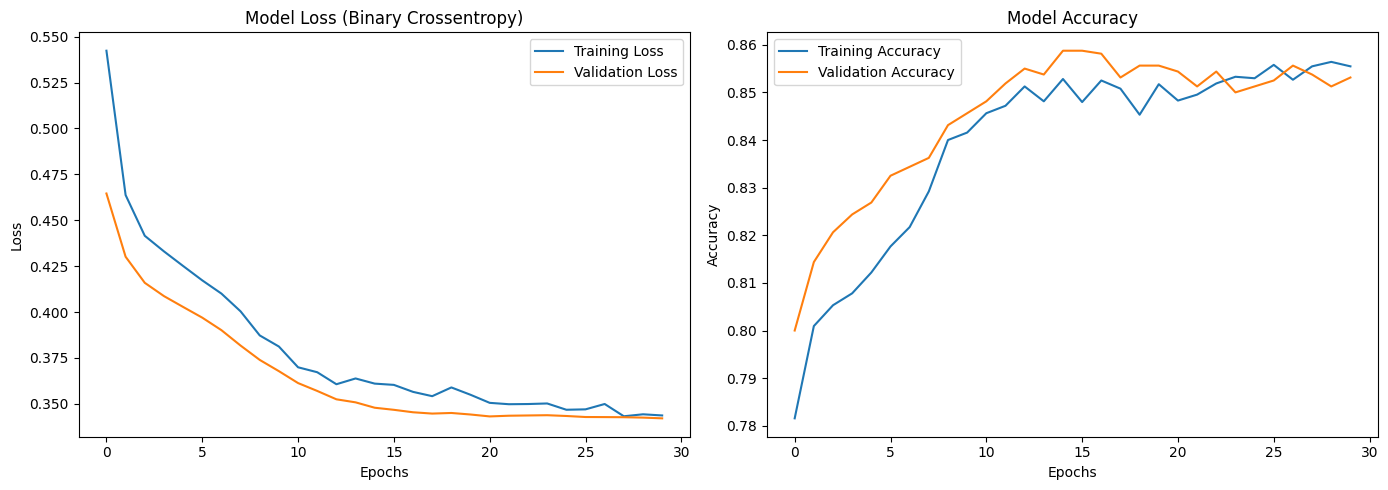

In [ ]:
class ChurnModelPipeline:
  def __init__(self, file_path):
    self.file_path = file_path
    self.model = None
    self.history = None
    self.X_train = None
    self.X_test = None
    self.y_train = None
    self.y_test = None
    self.scaler = StandardScaler()

  def load_data(self):
    try:
      df = pd.read_csv(self.file_path)
      print(f"File Loaded Successfully. Shape: {df.shape}")
      return df
    except Exception as e:
      print(f"Error: {e}")
      return None

  def preprocess_data(self, df):
    drop_cols = ["RowNumber", "CustomerId", "Surname"]
    print(f"Dropping columns: {drop_cols}")
    df = df.drop([c for c in drop_cols if c in df.columns], axis=1)

    if df.isnull().sum().sum() > 0:
      print("Filling missing values with mean")
      df.fillna(df.mean(), inplace=True)

    X = df.drop("Exited", axis=1)
    y = df["Exited"]

    cat_cols = [c for c in X.columns if X[c].dtype == "object"]
    num_cols = [c for c in X.columns if X[c].dtype != "object"]
    print(f"Categorical columns: {cat_cols}")

    preprocessor = ColumnTransformer(
        transformers=[
          ("num", "passthrough", num_cols),
          ("cat", OneHotEncoder(), cat_cols)
        ]
    )
    X_processed = preprocessor.fit_transform(X)

    self.X_train, self.X_test, self.y_train, self.y_test = train_test_split(X_processed, y, test_size=0.2, random_state=42)

    self.X_train = self.scaler.fit_transform(self.X_train)
    self.X_test = self.scaler.transform(self.X_test)

    print("Preprocessing and scaling completed successfully")

  def build_model(self):
    input_dim = self.X_train.shape[1]

    self.model = keras.Sequential([
      layers.Dense(16, activation="relu", input_shape=(input_dim,)),
      layers.Dropout(0.1),

      layers.Dense(8, activation="relu"),

      layers.Dense(1, activation="sigmoid")
    ])

    self.model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    print("Model built successfully")

  def train(self, epochs=50, batch_size=32):
    early_stopping = callbacks.EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)

    print(f"Starting training for {epochs} epochs")
    self.history = self.model.fit(
      self.X_train, self.y_train,
      validation_split=0.2,
      batch_size=batch_size,
      epochs=epochs,
      callbacks=[early_stopping],
      verbose=1
    )

  def evaluate_and_predict(self):
    y_pred_prob = self.model.predict(self.X_test)
    y_pred = (y_pred_prob > 0.5).astype(int).flatten()

    acc = accuracy_score(self.y_test, y_pred)
    print(f"\nTest Accuracy Score: {acc:.4f}")
    print("\nClassification Report:\n", classification_report(self.y_test, y_pred))

    comparison_df = pd.DataFrame({
        'Actual Label': self.y_test.values,
        'Predicted Label': y_pred,
        'Prediction Probability': y_pred_prob.flatten().round(4)
    }).head(10)

    print("\nPredictions (Actual vs Predicted):")
    print(comparison_df)

  def visualize_performance(self):
    hist = self.history.history
    epochs_range = range(len(hist['loss']))

    plt.figure(figsize=(14, 5))

    # Plot 1: Loss (Actual vs Validation)
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, hist['loss'], label='Training Loss')
    plt.plot(epochs_range, hist['val_loss'], label='Validation Loss')
    plt.title('Model Loss (Binary Crossentropy)')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    # Plot 2: Accuracy (Actual vs Validation)
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, hist['accuracy'], label='Training Accuracy')
    plt.plot(epochs_range, hist['val_accuracy'], label='Validation Accuracy')
    plt.title('Model Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
  pipeline = ChurnModelPipeline(file_path='/content/sample_data/Customer_Churn.csv')

  df = pipeline.load_data()
  pipeline.preprocess_data(df)
  pipeline.build_model()
  pipeline.train(epochs=30)
  pipeline.evaluate_and_predict()
  pipeline.visualize_performance()